<a href="https://colab.research.google.com/github/arago07/Egocentric-Hand-Occlusion-Segmentation/blob/main/Egocentric_Hand_Segmentation_DeepLabV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import drive

# 1. 구글 드라이브 마운트 (권한 허용 팝업 클릭)
drive.mount('/content/drive')

# 2. 작업할 폴더로 이동
%cd /content/drive/MyDrive/egocentric

print("구글 드라이브 연결 및 경로 설정 완료!")

Mounted at /content/drive
/content/drive/MyDrive/egocentric
구글 드라이브 연결 및 경로 설정 완료!


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch import ToTensorV2

class EgocentricDataset(Dataset):
  def __init__(self, root, json_file, transform=None):
    self.root = root
    self.coco = COCO(json_file)
    self.ids = list(self.coco.imgs.keys())
    self.transform = transform

  def __getitem__(self, index):
    # 1. image 불러오기
    img_id = self.ids[index]
    img_metadata = self.coco.loadImgs(img_id)[0]
    path = img_metadata['file_name']
    img = cv2.imread(os.path.join(self.root, path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. mask(정답) 생성
    ann_ids = self.coco.getAnnIds(imgIds=img_id)
    anns = self.coco.loadAnns(ann_ids)
    mask = np.zeros((img_metadata['height'], img_metadata['width'])) # mask를 검은색으로

    for ann in anns:
      # hand=1, bottle=2, cup=3
      mask = np.maximum(mask, self.coco.annToMask(ann) * ann['category_id']) # 겹치는 경우 대비 max 사용

    # 3. data 증강
    if self.transform:
      augmented = self.transform(image=img, mask=mask) # image, mask 동시에 augmentation
      img = augmented['image']
      mask = augmented['mask']

    return img, mask.long() # datatype: -> 'int64'

  def __len__(self):
    return len(self.ids)

# defining augmentation rule - training
train_transform = A.Compose([
    A.Resize(512, 512), # 모델 입력을 위해 크기 통일
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.5), # light changes
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# dataset 객체 생성
dataset = EgocentricDataset(root='dataset/images',
                             json_file='dataset/annotations/instances_default.json',
                             transform=train_transform)

print(f"총 {len(dataset)}개의 데이터가 준비되었습니다.")



loading annotations into memory...
Done (t=0.61s)
creating index...
index created!
총 60개의 데이터가 준비되었습니다.


The form of images: torch.Size([4, 3, 512, 512])
The form of masks: torch.Size([4, 512, 512])


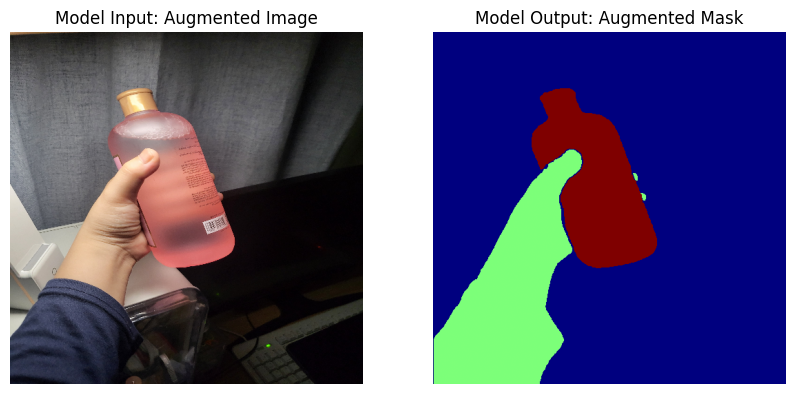

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# 1. DataLoader
train_loader = DataLoader(dataset, batch_size=4, shuffle=True) # to prevent memorizing answers

# 2. receiving data from dataloader using batch
images, masks = next(iter(train_loader))

print(f"The form of images: {images.shape}")
print(f"The form of masks: {masks.shape}")

# 3. check data before put in the model
img = images[0].numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

mask = masks[0].numpy()

# drawing
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Model Input: Augmented Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Model Output: Augmented Mask")
plt.imshow(mask, cmap='jet') # class number에 따라 다른 색상
plt.axis('off')

plt.show()

In [4]:
import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import torch.nn as nn

# 1. DeepLabV3
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)

# 2. modifying output layer
num_classes = 4 # 3 classes + 1 background

# 3. remove classifier, add new one
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1), stride=(1,1))

print(f"The number of output class: {num_classes}")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 163MB/s]


The number of output class: 4


In [5]:
import torch
import torch.optim as optim

# turn on the GPU in google colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"사용중인 엔진: {device}")

# setting loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # use 'Adam'

# setting epoch
num_epochs = 5

print("Started to train the model")

for epoch in range(num_epochs):
  model.train()
  epoch_loss = 0

  for images, masks in train_loader:
    images = images.to(device)
    masks = masks.to(device)

    # prediction - grading - updating gradient
    optimizer.zero_grad()
    outputs = model(images)['out'] # answers만
    loss = criterion(outputs, masks)
    loss.backward() # calculate new gradient
    optimizer.step() # update gradient

    epoch_loss += loss.item()

  avg_loss = epoch_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

print("Finished training the model")



사용중인 엔진: cuda
Started to train the model
Epoch [1/5] | Loss: 0.7925
Epoch [2/5] | Loss: 0.6256
Epoch [3/5] | Loss: 0.6012
Epoch [4/5] | Loss: 0.5607
Epoch [5/5] | Loss: 0.4977
Finished training the model


Result
-------------------------------
사용중인 엔진: cuda
Started to train the model

Epoch [1/5] | Loss: 0.7925

Epoch [2/5] | Loss: 0.6329

Epoch [3/5] | Loss: 0.5776

Epoch [4/5] | Loss: 0.5612

Epoch [5/5] | Loss: 0.5181

Finished training the model

In [6]:
import torch

# 1. 저장 위치 지정
save_path = '/content/drive/MyDrive/egocentric/my_deeplabv3_model.pth'

torch.save(model.state_dict(), save_path)

print(f"Finished Saving the File.")
print(f"저장 위치: {save_path}")

Finished Saving the File.
저장 위치: /content/drive/MyDrive/egocentric/my_deeplabv3_model.pth


## Experiment 1: no backlight data during the training

In [7]:
import torchvision
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

print("Prepare Experiment 1: Initializing gradient")

# Model Structure & Basic Knowledge of the Images
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = torchvision.models.segmentation.deeplabv3_resnet50(weights=weights)

# Output: 4 types
model.classifier[4] = torch.nn.Conv2d(256, 4, kernel_size=(1, 1), stride=(1, 1))
model = model.to(device)

print("Finished resetting")

Prepare Experiment 1: Initializing gradient
Finished resetting


In [8]:
# Train(40 pics): ordinary indoor light, sunlight
# Validation(10 pics): yellow color light from a desk stand
# Test(10 pics): strong backlight

from torch.utils.data import DataLoader, Subset

root_folder = 'dataset/images'
json_path = 'dataset/annotations/instances_default.json'

print(f"Start splitting...")

full_dataset = EgocentricDataset(root=root_folder, json_file=json_path, transform=train_transform)

# 1. Write the list of file names(the files are scattered)
sunlight_list = ['photo_001.jpeg'] + [f'photo_{i:03d}.jpeg' for i in range (7, 16)]
fluorescent_list = ['photo_006.jpeg'] + [f'photo_{i:03d}.jpeg' for i in range (47, 56)]
stand_lv1_list = ['photo_002.jpeg'] + [f'photo_{i:03d}.jpeg' for i in range (16, 25)]

stand_lv2_list = (['photo_004.jpeg'] +
                  [f'photo_{i:03d}.jpeg' for i in range (34, 36)] +
                  ['photo_036_1.jpeg'] +
                  ['photo_037.jpeg'] +
                  [f'photo_{i:03d}.jpeg' for i in range (56, 61)])

stand_yellow_list = ['photo_003.jpeg'] + [f'photo_{i:03d}.jpeg' for i in range (25, 34)]
backlight_list = ['photo_005.jpeg'] + [f'photo_{i:03d}.jpeg' for i in range (38, 47)]

# 2. Distribute the lists to Train/Validatioin/Test
train_list = sunlight_list + fluorescent_list + stand_lv1_list + stand_lv2_list
val_list = stand_yellow_list
test_list = backlight_list

# 3. Search index numbers in the dataset
train_indices, val_indices, test_indices = [], [], []

for idx, img_id in enumerate(full_dataset.ids):
  file_name = full_dataset.coco.imgs[img_id]['file_name']

  if file_name in train_list:
    train_indices.append(idx)
  elif file_name in val_list:
    val_indices.append(idx)
  elif file_name in test_list:
    test_indices.append(idx)

# 4. Split dataset into subsets using extracted indices and initialize DataLoaders
train_loader = DataLoader(Subset(full_dataset, train_indices), batch_size=4,shuffle=True)
val_loader = DataLoader(Subset(full_dataset, val_indices), batch_size=4, shuffle=False)
test_loader = DataLoader(Subset(full_dataset, test_indices), batch_size=4, shuffle=False)

print("Checked the Lists.")
print(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")


Start splitting...
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Checked the Lists.
Train: 40, Val: 10, Test: 10



------------------------------
Before

Epoch [1/5] | Loss: 0.7925

Epoch [2/5] | Loss: 0.6329

Epoch [3/5] | Loss: 0.5776

Epoch [4/5] | Loss: 0.5612

Epoch [5/5] | Loss: 0.5181

------------------------------
After

Epoch [1/5] | Loss: 0.4504

Epoch [2/5] | Loss: 0.3906

Epoch [3/5] | Loss: 0.3974

Epoch [4/5] | Loss: 0.3388

Epoch [5/5] | Loss: 0.3019


In [10]:
import torch
import torch.optim as optim

# setting loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # use 'Adam'

# setting epoch
num_epochs = 5

print("[Experiment 1] Started to train the model")

for epoch in range(num_epochs):
  model.train()
  epoch_loss = 0

  for images, masks in train_loader:
    images = images.to(device)
    masks = masks.to(device)

    # prediction - grading - updating gradient
    optimizer.zero_grad()
    outputs = model(images)['out'] # answers만
    loss = criterion(outputs, masks)
    loss.backward() # calculate new gradient
    optimizer.step() # update gradient

    epoch_loss += loss.item()

  avg_loss = epoch_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

print("Finished training the model")


[Experiment 1] Started to train the model
Epoch [1/5] | Loss: 0.9249
Epoch [2/5] | Loss: 0.5608
Epoch [3/5] | Loss: 0.5060
Epoch [4/5] | Loss: 0.4473
Epoch [5/5] | Loss: 0.4219
Finished training the model


[Experiment 1] Result
---------------------------

Epoch [1/5] | Loss: 0.9249

Epoch [2/5] | Loss: 0.5608

Epoch [3/5] | Loss: 0.5060

Epoch [4/5] | Loss: 0.4473

Epoch [5/5] | Loss: 0.4219


In [13]:
import numpy as np
print("[Experiment 1] Final mIOU score")

def calculate_iou(pred, target, num_classes):
  ious = []
  pred = pred.view(-1)
  target = target.view(-1)

  for cls in range(num_classes):
    pred_inds = pred == cls
    target_inds = target == cls
    intersection = (pred_inds[target_inds]).long().sum().item()
    union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection # T/F -> number(1.0/0.0)

    if union == 0:
      ious.append(float('nan'))
    else:
      ious.append(float(intersection) / float(union))

  return ious

model.eval()
class_names = {0: "Background", 1: "Hand", 2: "Bottle", 3: "Cup"}
total_ious = {0: [], 1: [], 2: [], 3: []}
num_classes = 4

with torch.no_grad():
  for images, masks in val_loader:
    images = images.to(device)
    masks = masks.to(device)

    outputs = model(images)['out']
    preds = torch.argmax(outputs, dim=1)

    for i in range(images.size(0)):
      ious = calculate_iou(preds[i], masks[i], num_classes=4)
      for cls in range(num_classes):
        if not np.isnan(ious[cls]):
          total_ious[cls].append(ious[cls])

print("-" * 40)
for cls in range(num_classes):
  cls_iou = np.mean(total_ious[cls]) * 100 # for percentage(%)
  print(f"\n{class_names[cls]}: {cls_iou:.2f}%\n")

mean_iou_all = np.nanmean([np.mean(total_ious[c]) for c in range(num_classes)]) * 100
print("-" * 40)
print(f"\n[Experiment 1] Mean IoU: {mean_iou_all:.2f}%")


[Experiment 1] Final mIOU score
----------------------------------------

Background: 83.66%


Hand: 42.64%


Bottle: 45.11%


Cup: 0.05%

----------------------------------------

[Experiment 1] Mean IoU: 42.87%


Test the Inference Ability of the model in Zero-Shot environment



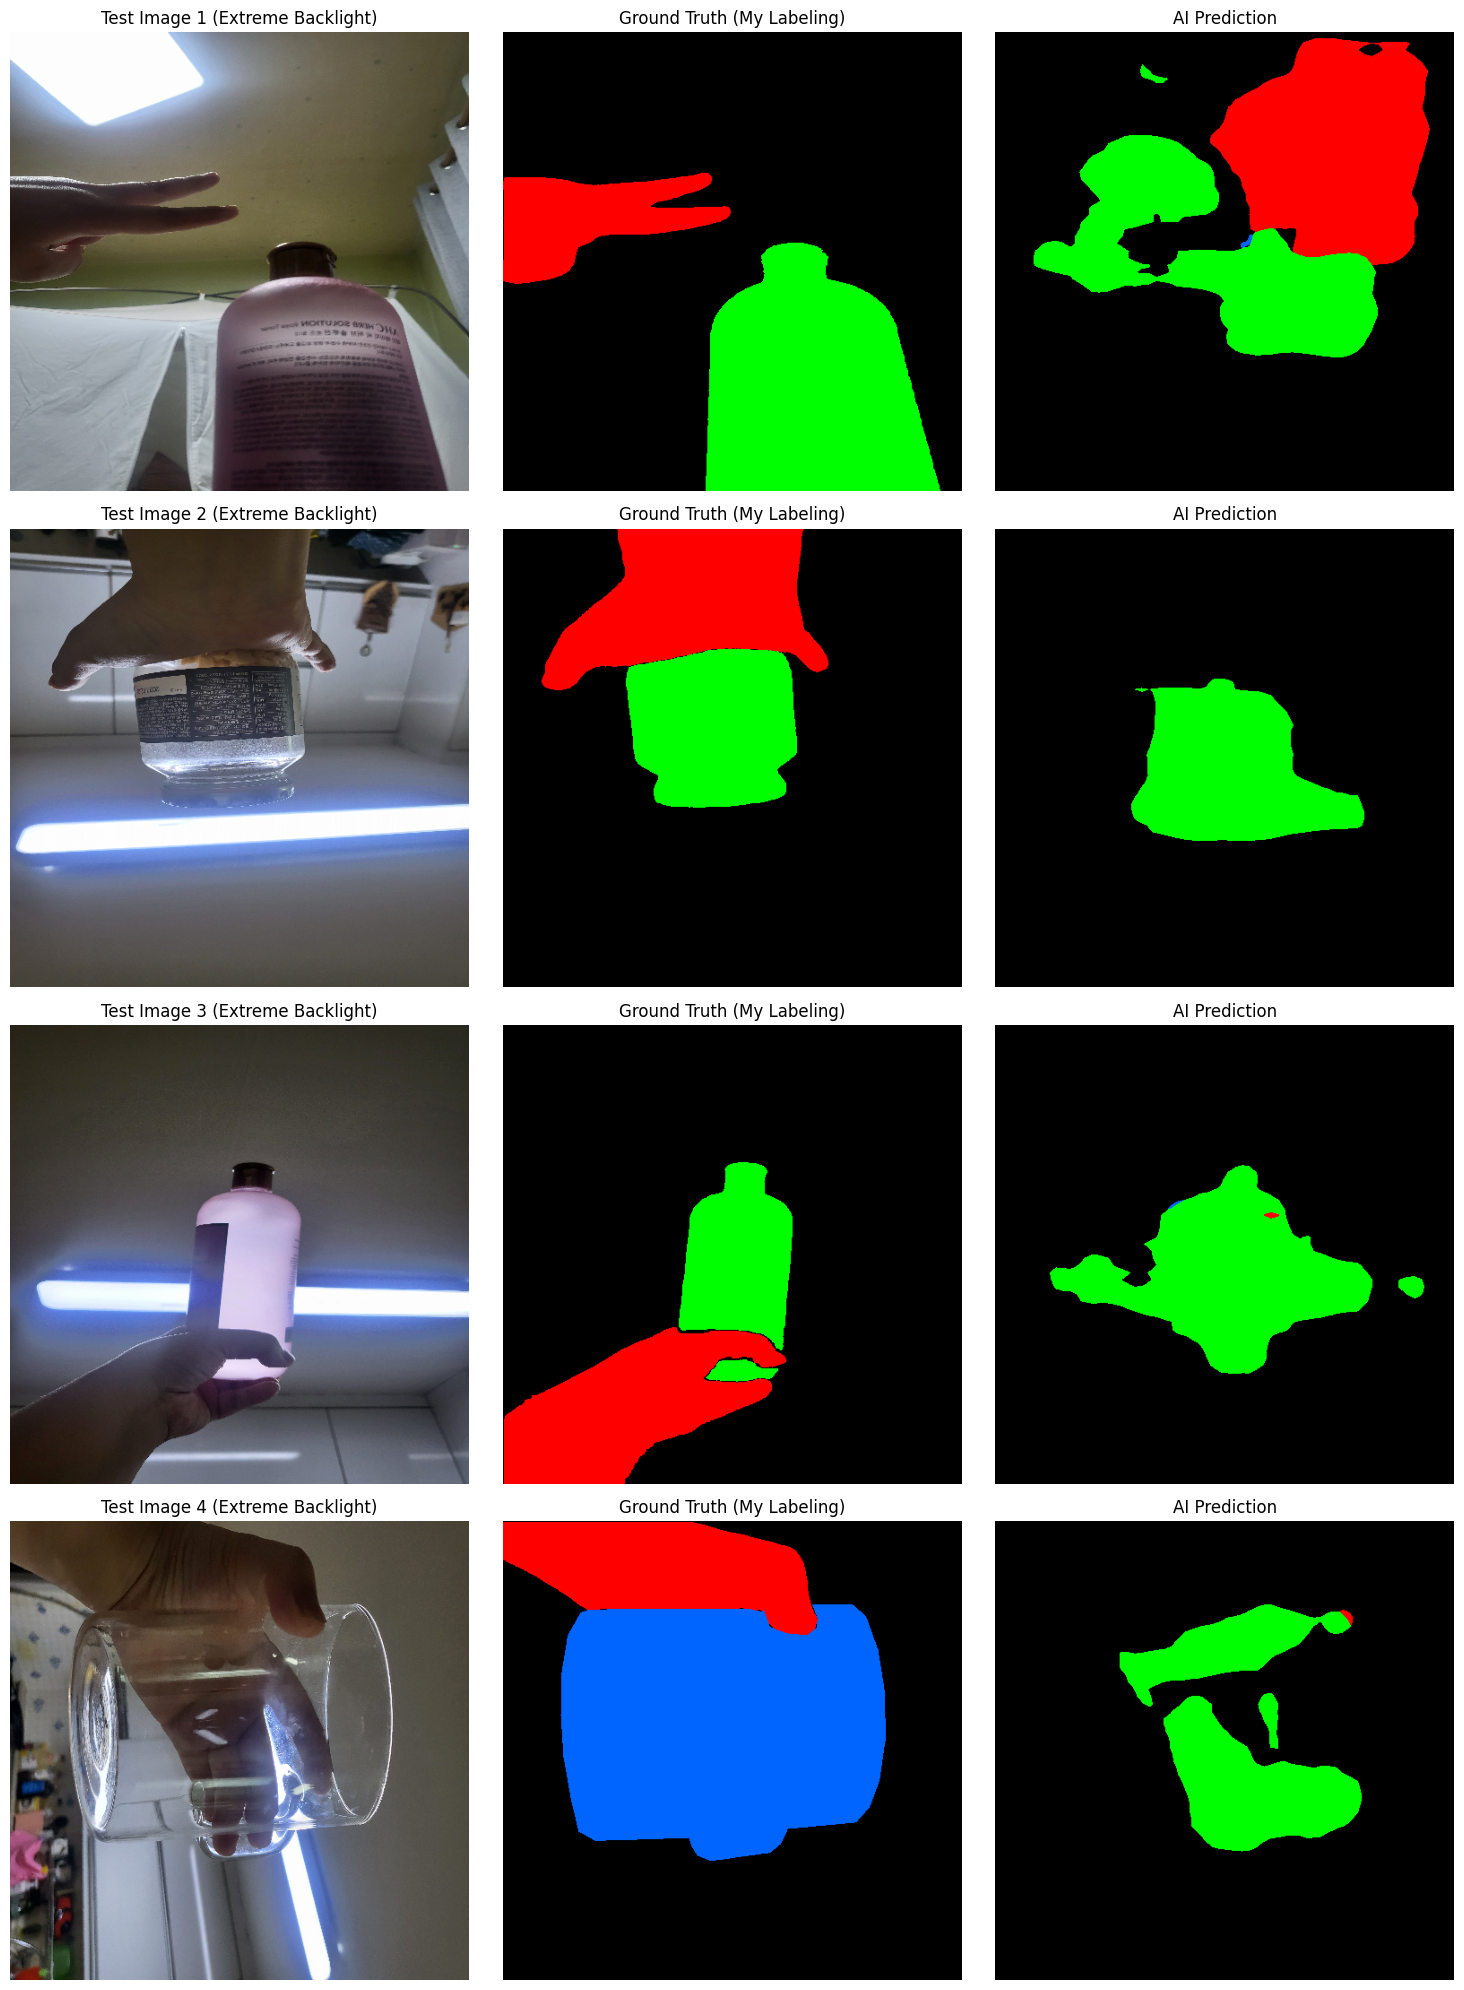

In [14]:
# Visualization

import matplotlib.pyplot as plt
import numpy as np
import torch

print("Test the Inference Ability of the model in Zero-Shot environment\n")

# 1. Set the Color Palette
colors = np.array([
    [0, 0, 0],      # backgraound(black, 0)
    [255, 0, 0],    # hand(red, 1)
    [0, 255, 0],    # bottle(green, 2)
    [0, 100, 255]   # cup(blue, 3)
], dtype=np.uint8)

# 2. Change the Model as 'Test Mode' - NO TRAINING
model.eval()

# 3. Pull of a batch
images, true_masks = next(iter(test_loader))
images = images.to(device)

# 4. Solve Problems
with torch.no_grad():
  outputs = model(images)['out']
  predictions = torch.argmax(outputs, dim=1).cpu().numpy()

# 5. Bring the Image from GPU -> CPU
images = images.cpu().numpy()
true_masks = true_masks.numpy()

# 6. Draw the Visualized Results
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for i in range(4):
  # (1) Image Color Restoration
  img = images[i].transpose(1, 2, 0) # transpose the shape of the data
  std = np.array([0.229, 0.224, 0.225])
  img = std * img + mean
  img = np.clip(img, 0, 1)

  # (2) Color pred & anns
  pred_color = colors[predictions[i]]
  true_color = colors[true_masks[i]]

  # (3) Visualize the Results
  # 1st column - Original
  axes[i, 0].imshow(img)
  axes[i, 0].set_title(f"Test Image {i+1} (Extreme Backlight)")
  axes[i, 0].axis('off')

  # 2nd column - Annotations
  axes[i, 1].imshow(true_color)
  axes[i, 1].set_title(f"Ground Truth (My Labeling)")
  axes[i, 1].axis('off')

  # 3rd column - AI Prediction
  axes[i, 2].imshow(pred_color)
  axes[i, 2].set_title("AI Prediction")
  axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('experiment1_failed_backlight.png', dpi=300, bbox_inches='tight')
plt.show()



The model was failed to distinguish objects.

-> Decided to train the model again with square-shaped backlight

## Experiment 2: Retraining the model with 3 squared-shape backlight

In [15]:
from torch.utils.data import DataLoader, Subset

print("Start splitting...")

# 1. Lists
sunlight_list = ['photo_001.jpeg'] + [f'photo_{i:03d}.jpeg' for i in range (7, 16)]
fluorescent_list = ['photo_006.jpeg'] + [f'photo_{i:03d}.jpeg' for i in range (47, 56)]
stand_lv1_list = ['photo_002.jpeg'] + [f'photo_{i:03d}.jpeg' for i in range (16, 25)]

stand_lv2_list = (['photo_004.jpeg'] +
                  [f'photo_{i:03d}.jpeg' for i in range (34, 36)] +
                  ['photo_036_1.jpeg'] +
                  ['photo_037.jpeg'] +
                  [f'photo_{i:03d}.jpeg' for i in range (56, 61)])

# (1) Splitting the Photos with Backlights
square_backlight = ['photo_005.jpeg', 'photo_045.jpeg', 'photo_046.jpeg']
bar_backlight = [f'photo_{i:03d}.jpeg' for i in range (38, 45)]

# (2) Splitting the Photos with yellow light
yellow_normal = [f'photo_{i:03d}.jpeg' for i in range (25, 29)] + ['photo_031.jpeg'] + ['photo_033.jpeg'] + ['photo_003.jpeg']
yellow_hard = ['photo_029.jpeg', 'photo_030.jpeg', 'photo_032.jpeg']

# 2. Integrate the Lists
train_list = sunlight_list + fluorescent_list + stand_lv1_list + stand_lv2_list + square_backlight
val_list = yellow_normal
test_list = yellow_hard + bar_backlight

# 3. Search the Indices & Generate DataLoaders
train_indices, val_indices, test_indices = [], [], []

for idx, img_id in enumerate(full_dataset.ids):
  file_name = full_dataset.coco.imgs[img_id]['file_name']

  if file_name in train_list:
    train_indices.append(idx)
  elif file_name in val_list:
    val_indices.append(idx)
  elif file_name in test_list:
    test_indices.append(idx)

train_loader = DataLoader(Subset(full_dataset, train_indices), batch_size=4, shuffle=True)
val_loader = DataLoader(Subset(full_dataset, val_indices), batch_size=4, shuffle=False)
test_loader = DataLoader(Subset(full_dataset, test_indices), batch_size=4, shuffle=False)

print("\nChecked the Lists.")
print(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")


Start splitting...

Checked the Lists.
Train: 43, Val: 7, Test: 10


In [16]:
import torchvision
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

print("Prepare Experiment 2: Initializing gradient")

# Model Structure & Basic Knowledge of the Images
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = torchvision.models.segmentation.deeplabv3_resnet50(weights=weights)

# Output: 4 types
model.classifier[4] = torch.nn.Conv2d(256, 4, kernel_size=(1, 1), stride=(1, 1))

model = model.to(device)
print("Finished resetting")

Prepare Experiment 2: Initializing gradient
Finished resetting


In [17]:
import torch
import torch.optim as optim

# setting loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # use 'Adam'

# setting epoch
num_epochs = 5

print("Experiment 2: Started to train the model")

for epoch in range(num_epochs):
  model.train()
  epoch_loss = 0

  for images, masks in train_loader:
    images = images.to(device)
    masks = masks.to(device)

    # prediction - grading - updating gradient
    optimizer.zero_grad()
    outputs = model(images)['out'] # answers만
    loss = criterion(outputs, masks)
    loss.backward() # calculate new gradient
    optimizer.step() # update gradient

    epoch_loss += loss.item()

  avg_loss = epoch_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

print("Finished training the model")



Experiment 2: Started to train the model
Epoch [1/5] | Loss: 0.8237
Epoch [2/5] | Loss: 0.5777
Epoch [3/5] | Loss: 0.5153
Epoch [4/5] | Loss: 0.4652
Epoch [5/5] | Loss: 0.5153
Finished training the model


In [21]:
import numpy as np
print("[Experiment 2] Final mIOU score")

def calculate_iou(pred, target, num_classes):
  ious = []
  pred = pred.view(-1)
  target = target.view(-1)

  for cls in range(num_classes):
    pred_inds = pred == cls
    target_inds = target == cls
    intersection = (pred_inds[target_inds]).long().sum().item()
    union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection # T/F -> number(1.0/0.0)

    if union == 0:
      ious.append(float('nan')) == 0
    else:
      ious.append(float(intersection) / float(union))

  return ious

model.eval()
class_names = {0: "Background", 1: "Hand", 2: "Bottle", 3: "Cup"}
total_ious = {0: [], 1: [], 2: [], 3: []}
num_classes = 4

with torch.no_grad():
  for images, masks in val_loader:
    images = images.to(device)
    masks = masks.to(device)

    outputs = model(images)['out']
    preds = torch.argmax(outputs, dim=1)

    for i in range(images.size(0)):
      ious = calculate_iou(preds[i], masks[i], num_classes=4)
      for cls in range(num_classes):
        if not np.isnan(ious[cls]):
          total_ious[cls].append(ious[cls])

print("-" * 40)
for cls in range(num_classes):
  cls_iou = np.mean(total_ious[cls]) * 100 # for percentage(%)
  print(f"\n{class_names[cls]}: {cls_iou:.2f}%\n")

mean_iou_all = np.nanmean([np.mean(total_ious[c]) for c in range(num_classes)]) * 100
print("-" * 40)
print(f"\n[Experiment 2] Mean IoU: {mean_iou_all:.2f}%")


[Experiment 2] Final mIOU score
----------------------------------------

Background: 83.25%


Hand: 55.24%


Bottle: 47.96%


Cup: 0.00%

----------------------------------------

[Experiment 2] Mean IoU: 46.61%


Test the Inference Ability in Few-Shot Target Domain



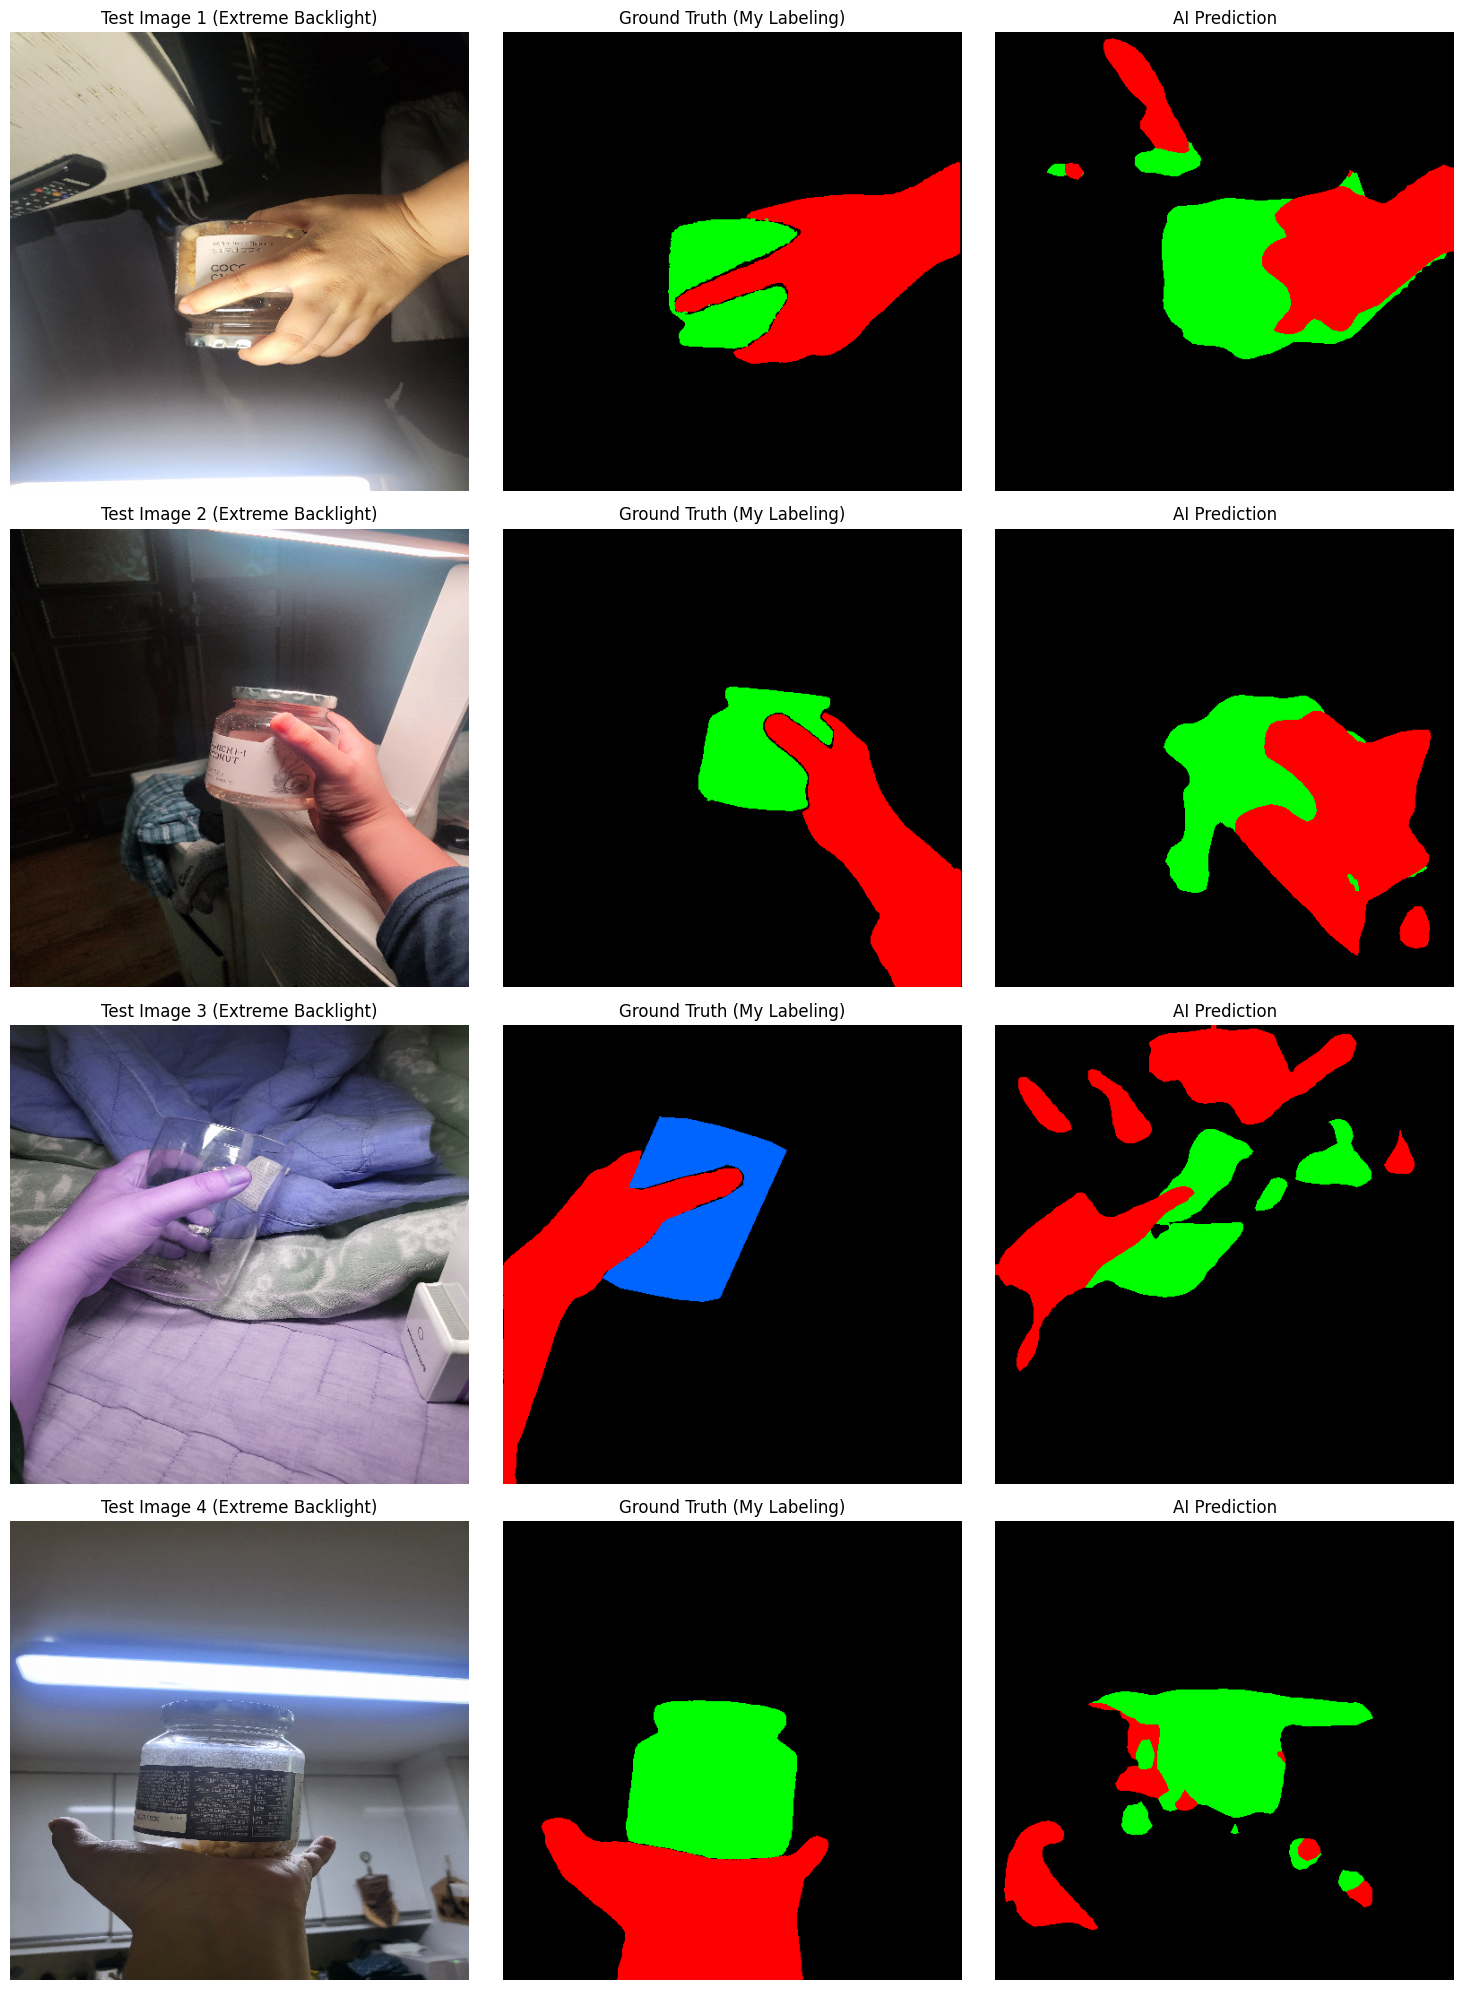

In [23]:
# Visualization

import matplotlib.pyplot as plt
import numpy as np
import torch

print("Test the Inference Ability in Few-Shot Target Domain\n")
# 1. Set the Color Palette
colors = np.array([
    [0, 0, 0],      # backgraound(black, 0)
    [255, 0, 0],    # hand(red, 1)
    [0, 255, 0],    # bottle(green, 2)
    [0, 100, 255]   # cup(blue, 3)
], dtype=np.uint8)

# 2. Change the Model as 'Test Mode' - NO TRAINING
model.eval()

# 3. Pull of a batch
images, true_masks = next(iter(test_loader))
images = images.to(device)

# 4. Solve Problems
with torch.no_grad():
  outputs = model(images)['out']
  predictions = torch.argmax(outputs, dim=1).cpu().numpy()

# 5. Bring the Image from GPU -> CPU
images = images.cpu().numpy()
true_masks = true_masks.numpy()

# 6. Draw the Visualized Results
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for i in range(4):
  # (1) Image Color Restoration
  img = images[i].transpose(1, 2, 0) # transpose the shape of the data
  std = np.array([0.229, 0.224, 0.225])
  img = std * img + mean
  img = np.clip(img, 0, 1)

  # (2) Color pred & anns
  pred_color = colors[predictions[i]]
  true_color = colors[true_masks[i]]

  # (3) Visualize the Results
  # 1st column - Original
  axes[i, 0].imshow(img)
  axes[i, 0].set_title(f"Test Image {i+1} (Extreme Backlight)")
  axes[i, 0].axis('off')

  # 2nd column - Annotations
  axes[i, 1].imshow(true_color)
  axes[i, 1].set_title(f"Ground Truth (My Labeling)")
  axes[i, 1].axis('off')

  # 3rd column - AI Prediction
  axes[i, 2].imshow(pred_color)
  axes[i, 2].set_title("AI Prediction")
  axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('experiment2_successful_backlight.png', dpi=300, bbox_inches='tight')
plt.show()



## 🏆 Conclusion & Future Work

This project analyzed the impact of extreme illumination changes (e.g., backlight) on Semantic Segmentation models in an Egocentric vision environment and demonstrated how targeting specific model weaknesses can improve performance.

### 💡 1. Key Insight: The Power of Data-Centric AI
* Instead of simply increasing the dataset size, adding just 3 'Hard Example' (extreme backlight) images successfully addressed a specific domain failure.

* This proves that identifying and targeting a model's failure points (Edge Cases) is a highly data-efficient strategy for enhancing robustness in specialized environments without large-scale data collection.

### 📈 2. Quantitative Achievements (mIOU Improvement)
* **Hand Recognition Surge:** 42.64% ➡️ **55.24% (+12.60%p)**
* **Mean IoU (mIOU) Growth:** 42.87% ➡️ **46.61% (+3.74%p)**
* Despite the loss of color (skin tone) information in backlight conditions, the additional data successfully forced the model to learn the intrinsic **morphology and silhouette** of the objects.

### 🚀 3. Limitations
* Observation: While both bottles and cups suffer from severe occlusion in egocentric views, the 'Cup' class yielded a 0% mIOU, unlike the 'Bottle' class.

* Root Cause Analysis: The fundamental difference lies in Transparency. While bottles provide opaque visual cues (e.g., labels, caps, colors), transparent cups allow the background and hand pixels to pass through. This makes it extremely difficult for the model to extract consistent visual features, especially when combined with occlusion.

### 🛠️ 4. Next Step: Strategic Troubleshooting
* Before advancing to broader theoretical architectures, a troubleshooting phase is planned to overcome the current 'Cup' recognition failure.

* The goal is to evaluate if algorithmic refinements can compensate for the lack of distinct visual features:

  1. **Data Augmentation:** Utilizing Color Jittering or MixUp to force the model to focus on the subtle edge boundaries of transparent objects.

  2. **Loss Weighting:**
   Applying Focal Loss or class-specific weights to increase the penalty for misclassifying the 'Cup' pixels, forcing the model to prioritize this underrepresented class.